In [1]:
suppressMessages({
    library(Seurat)
    library(SeuratWrappers)
    library(ggplot2)
    library(dplyr)
    library(SCP)
    library(harmony)
    library(clustree)
    library(ComplexHeatmap)
    library(RColorBrewer)
    library(clusterProfiler)
    library(KEGG.db)
    library(org.Hs.eg.db)
    library(cowplot)
    library(CellChat)
    library(SCopeLoomR)
    library(AUCell)
    library(KernSmooth)
    library(SCENIC)
    library(anndata)
    library(reticulate)
    library(ggpubr)
    library(reshape2)
})

# scRNA

## QC
1. get sample name and group name   
3. Filter cells: nCount_RNA < 15000 & nFeature_RNA > 200 & nFeature_RNA < 6000 & percent.mt < 10

In [72]:
sampledf = read.csv("scRNA_sample.txt", header = F)
groupdf = read.table("grouplist.txt", header = F, sep = "\t")
colnames(groupdf) = c("sample", "group")
samplelist = sampledf$V1

In [73]:
data.list = lapply(samplelist, function(x){
    print(x)
    obj = readRDS(file.path("DoubleFinder", x, "result.rds"))
    obj$Sample = x
    return(obj)
})

[1] "AIS1AC"
[1] "AIS1TC"
[1] "AIS2AC"
[1] "AIS2TC"
[1] "AIS3AC"
[1] "AIS3TC"
[1] "AIS4TC"
[1] "AIS7AC"
[1] "AIS8AC"
[1] "CON1LC"
[1] "CON3LC"
[1] "CON3RC"
[1] "CON7RC"


In [74]:
data = merge(data.list[[1]], data.list[-1])
data$Group = groupdf$group[match(data$Sample, groupdf$sample)]

In [75]:
data$percent.mt = PercentageFeatureSet(data, pattern = "MT-")

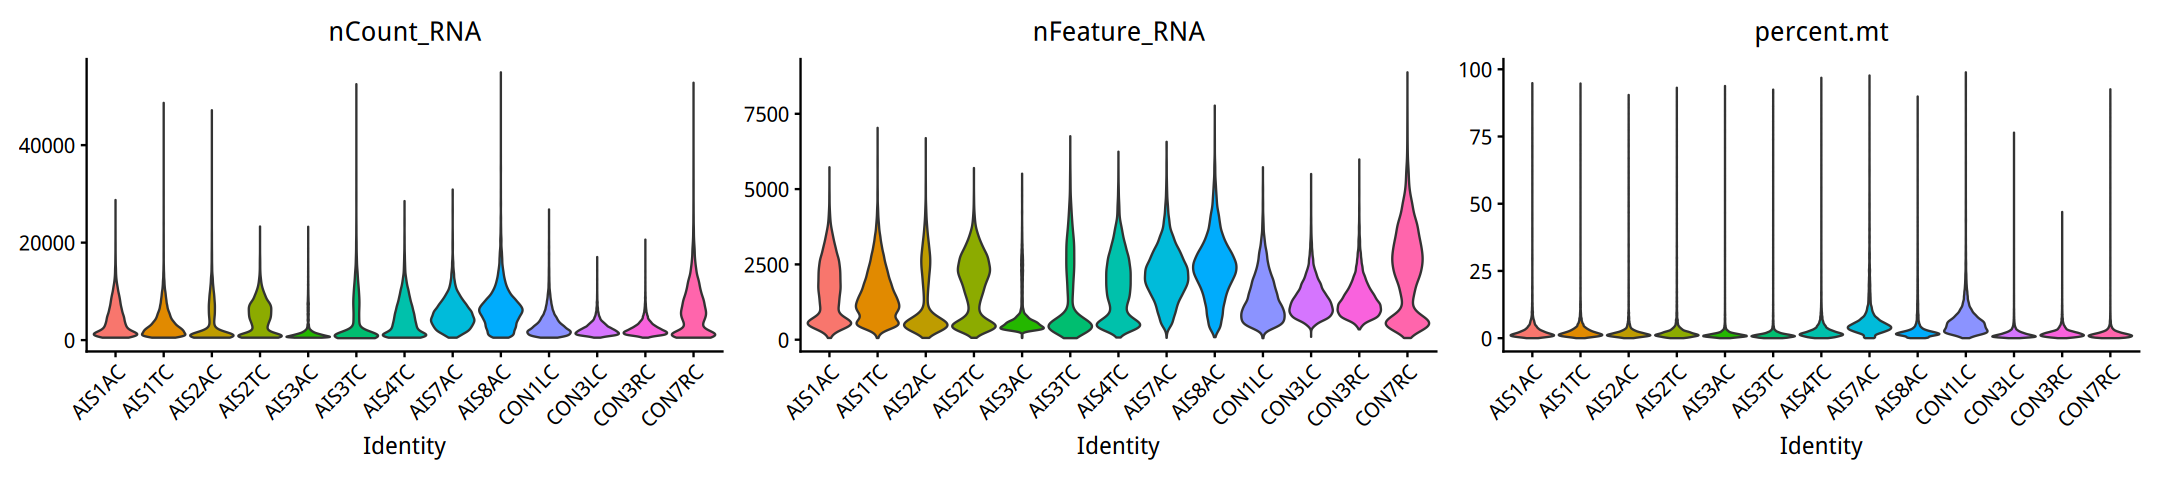

In [76]:
options(repr.plot.width = 18, repr.plot.height = 4)
VlnPlot(data, group.by = "Sample", features = c("nCount_RNA", "nFeature_RNA", "percent.mt"), pt.size = 0, raster = FALSE) + NoLegend()
outdir = "result/1.QC/scRNA"
if (!dir.exists(outdir)) dir.create(outdir, recursive = TRUE)
ggsave(file.path(outdir, "QC_before.pdf"), width = 18, height = 4)

In [24]:
data = subset(data, nCount_RNA < 15000 & nFeature_RNA > 200 & nFeature_RNA < 6000 & percent.mt < 10)

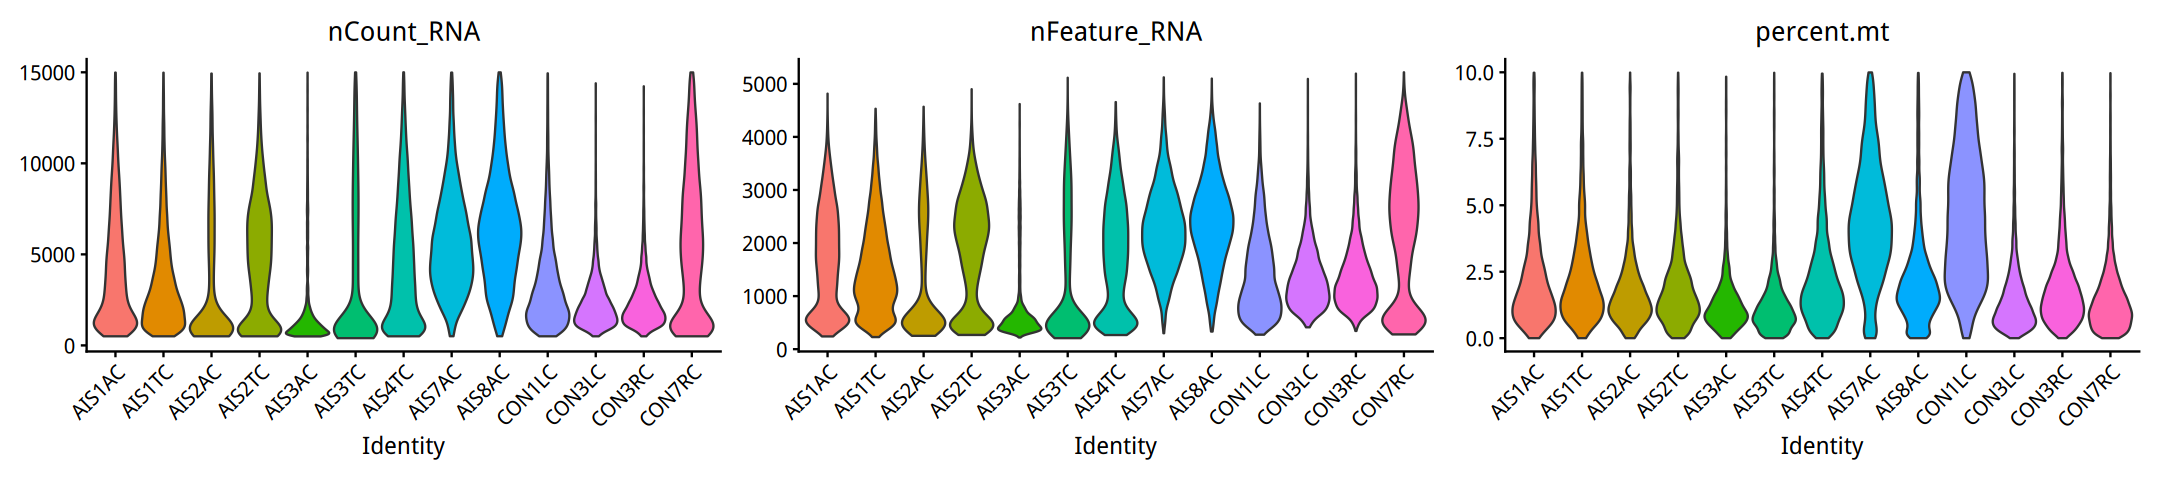

In [3]:
options(repr.plot.width = 18, repr.plot.height = 4)
VlnPlot(data, group.by = "Sample", features = c("nCount_RNA", "nFeature_RNA", "percent.mt"), pt.size = 0, raster = FALSE) + NoLegend()
outdir = "result/1.QC/scRNA"
if (!dir.exists(outdir)) dir.create(outdir, recursive = TRUE)
ggsave(file.path(outdir, "QC_after.pdf"), width = 18, height = 4)

In [4]:
table(data$Sample)


AIS1AC AIS1TC AIS2AC AIS2TC AIS3AC AIS3TC AIS4TC AIS7AC AIS8AC CON1LC CON3LC 
  7221  11463   5085   6355   4773   4569   9558   8469  12082   9547  12774 
CON3RC CON7RC 
 11395   7799 

## Dimensionality and Reduction

In [28]:
data = NormalizeData(data, verbose = F) %>% 
    FindVariableFeatures(verbose = F) %>% 
    ScaleData(verbose = F) %>% 
    RunPCA(verbose = F)

When using repel, set xnudge and ynudge to 0 for optimal results

Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”


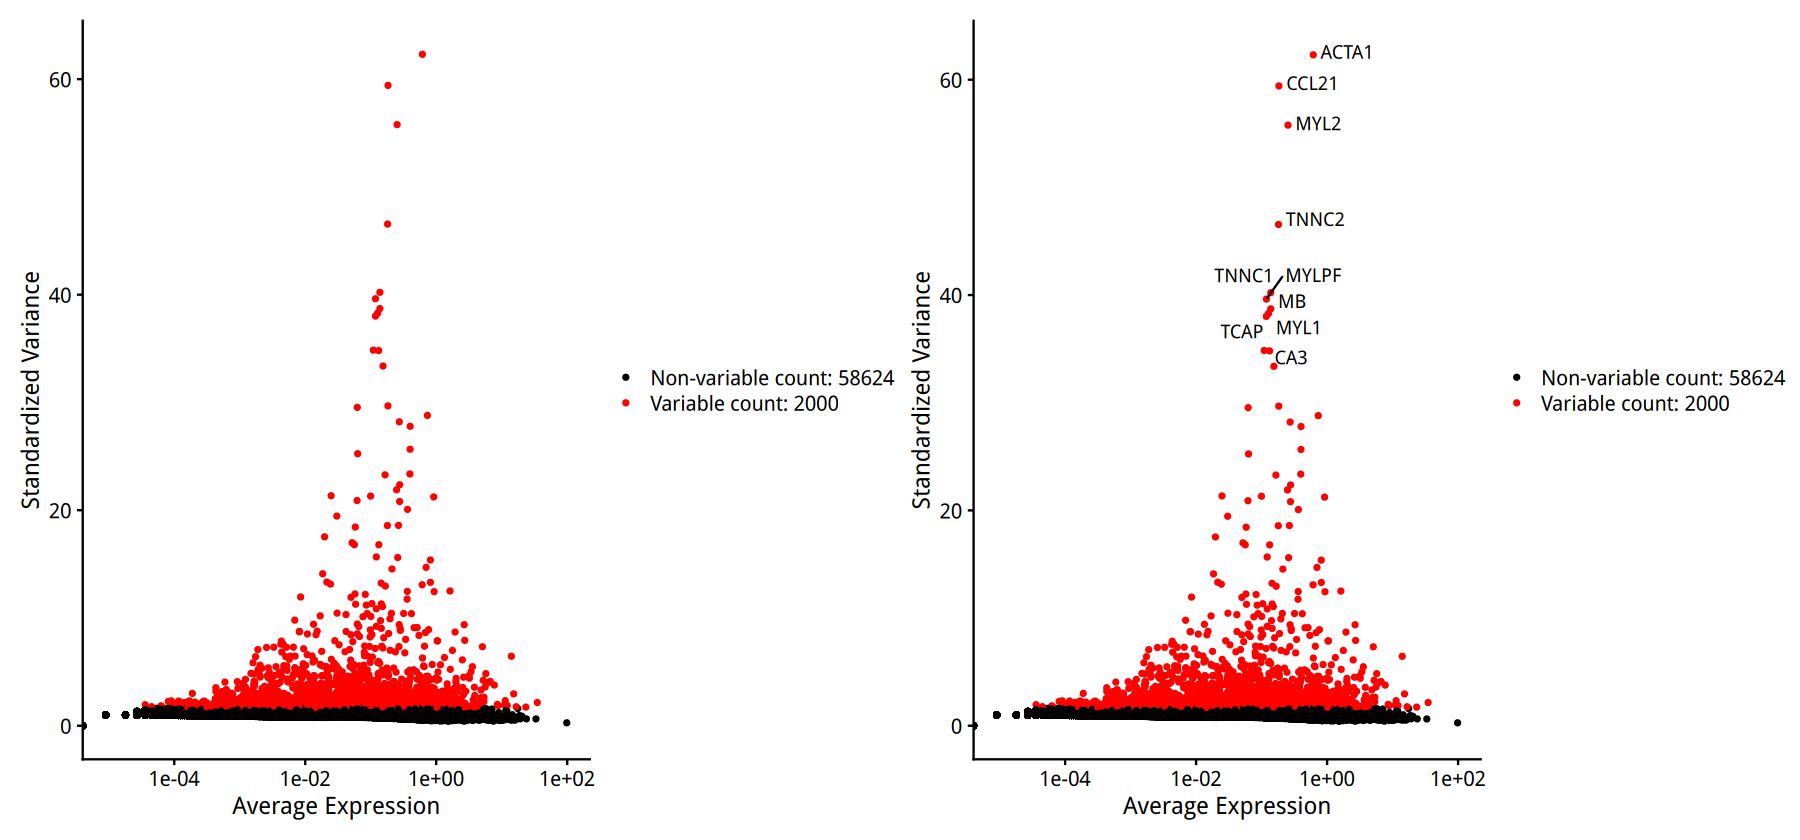

In [13]:
options(repr.plot.width = 15, repr.plot.height = 7)
top10 <- head(VariableFeatures(data), 10)
plot1 <- VariableFeaturePlot(data)
plot2 <- LabelPoints(plot = plot1, points = top10, repel = TRUE)
plot1 + plot2

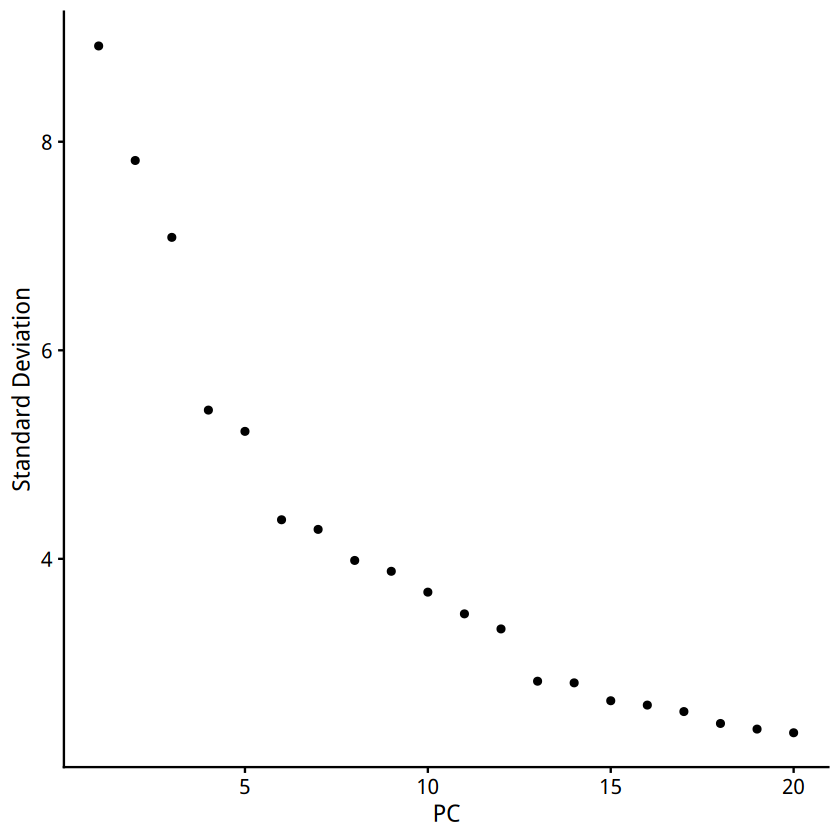

In [29]:
options(repr.plot.width = 7, repr.plot.height = 7)
ElbowPlot(data)

In [41]:
dims = 1:15
data = RunHarmony(data, group.by.vars = "Sample", verbose = F)
data = RunUMAP(data, dims = dims, reduction = "harmony", verbose = F)
data = FindNeighbors(data, dims = dims, reduction = "harmony", verbose = F)
data = FindClusters(data, resolution = 1:10/10, verbose = F)

Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 5554500)”
Warning message:
“Invalid name supplied, making object name syntactically valid. New object name is Seurat..ProjectDim.RNA.harmony; see ?make.names for more details on syntax validity”


In [42]:
colnames(data@meta.data)

[1] "orig.ident"         "nCount_RNA"         "nFeature_RNA"      
 [4] "stim"               "RNA_snn_res.0.8"    "seurat_clusters"   
 [7] "score"              "DF.classifications" "Sample"            
[10] "Group"              "percent.mt"         "RNA_snn_res.0.1"   
[13] "RNA_snn_res.0.2"    "RNA_snn_res.0.3"    "RNA_snn_res.0.4"   
[16] "RNA_snn_res.0.5"    "RNA_snn_res.0.6"    "RNA_snn_res.0.7"   
[19] "RNA_snn_res.0.9"    "RNA_snn_res.1"      "cluster"

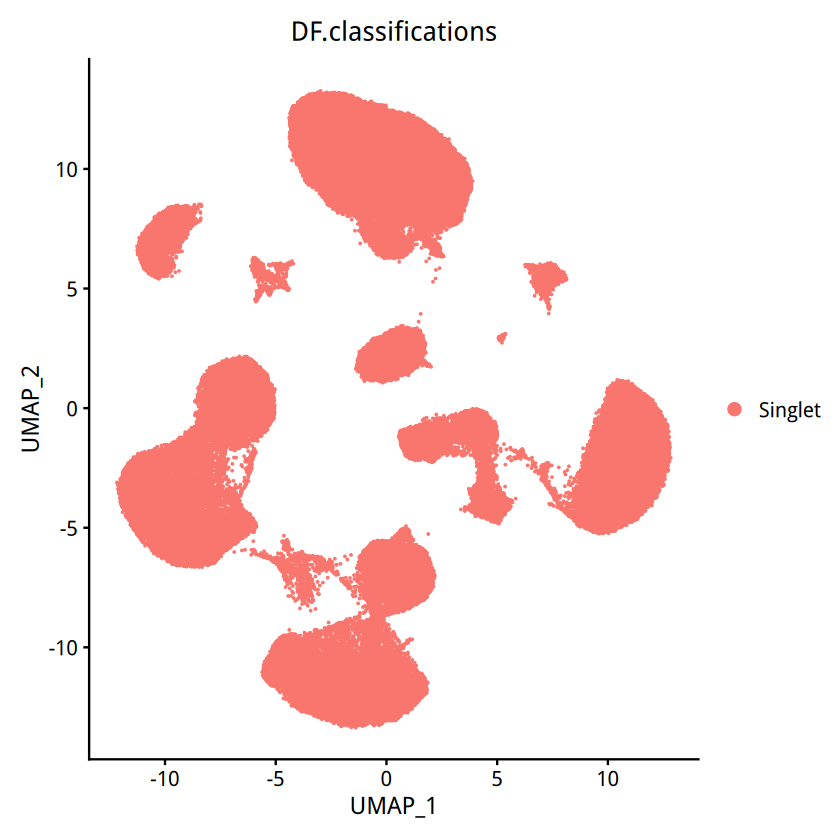

In [69]:
options(repr.plot.width = 7, repr.plot.height = 7)
DimPlot(data, group.by = "DF.classifications", raster = FALSE)
outdir = "result/2.UMAP/scRNA"
if (!dir.exists(outdir)) dir.create(outdir, recursive = TRUE)
ggsave(file.path(outdir, "umap.DoubletFinder.pdf"), width = 7, height = 7)

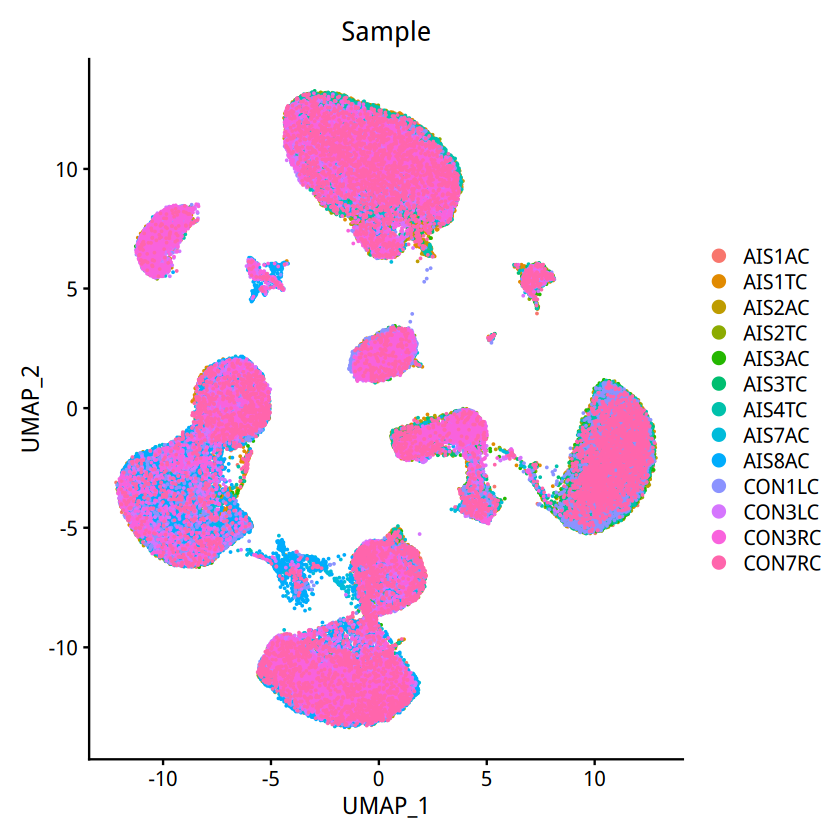

In [70]:
DimPlot(data, group.by = "Sample", raster = FALSE)
outdir = "result/2.UMAP/scRNA"
if (!dir.exists(outdir)) dir.create(outdir, recursive = TRUE)
ggsave(file.path(outdir, "umap.sample.pdf"), width = 7, height = 7)

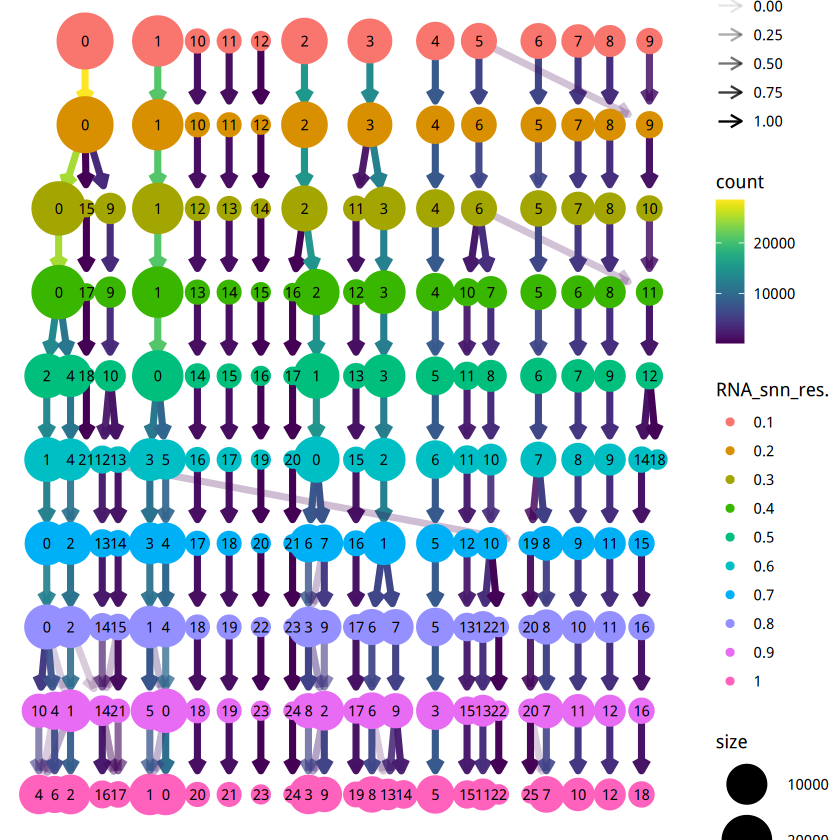

In [71]:
options(repr.plot.width = 7, repr.plot.height = 7)
clustree(data, prefix = "RNA_snn_res.")
outdir = "result/2.UMAP/scRNA"
if (!dir.exists(outdir)) dir.create(outdir, recursive = TRUE)
ggsave(file.path(outdir, "clustree.pdf"), width = 7, height = 7)

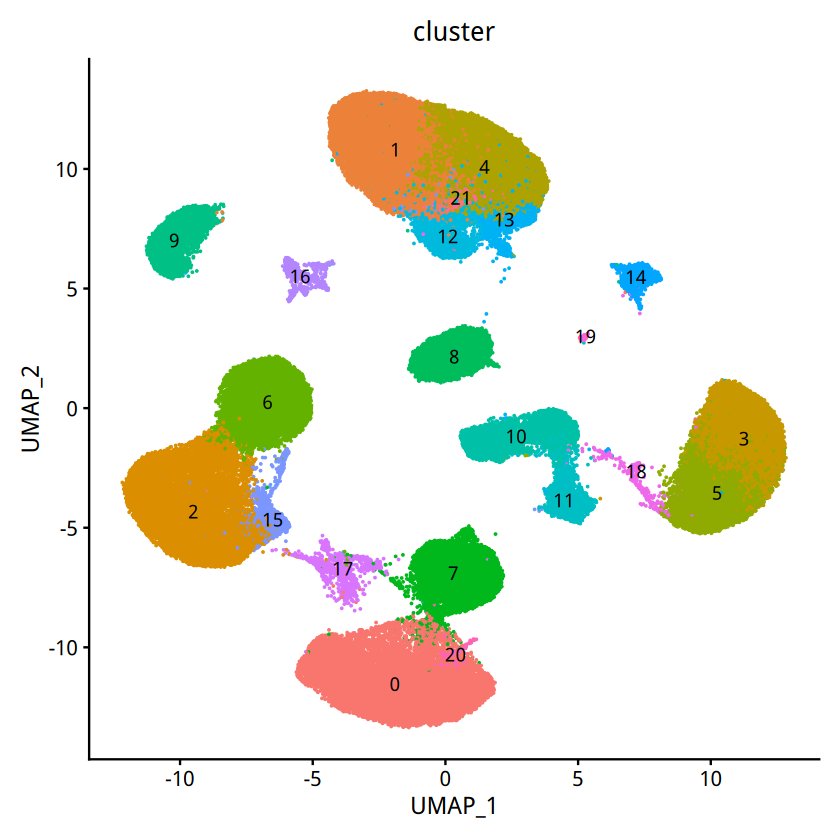

In [45]:
Idents(data) = "RNA_snn_res.0.6"
data$cluster = Idents(data)
DimPlot(data, group.by = "cluster", raster = FALSE, label = TRUE) + NoLegend()
outdir = "result/2.UMAP/scRNA"
if (!dir.exists(outdir)) dir.create(outdir, recursive = TRUE)
ggsave(file.path(outdir, "umap.cluster.pdf"), width = 7, height = 7)

In [46]:
saveRDS(data, "result/scRNA_seurat.rds")

## Define clusters
To Define clusters, we should to get the top markers for every clusters.

In [3]:
data = readRDS("result/scRNA_seurat.rds")

In [4]:
colnames(data@meta.data)

[1] "orig.ident"         "nCount_RNA"         "nFeature_RNA"      
 [4] "stim"               "RNA_snn_res.0.8"    "seurat_clusters"   
 [7] "score"              "DF.classifications" "Sample"            
[10] "Group"              "percent.mt"         "RNA_snn_res.0.1"   
[13] "RNA_snn_res.0.2"    "RNA_snn_res.0.3"    "RNA_snn_res.0.4"   
[16] "RNA_snn_res.0.5"    "RNA_snn_res.0.6"    "RNA_snn_res.0.7"   
[19] "RNA_snn_res.0.9"    "RNA_snn_res.1"      "cluster"

In [5]:
df = data.frame(table(data$Sample, data$Group))
colnames(df) = c("Sample", "Group", "Cell_Number")
df = df[df$Cell_Number != 0,]
write.table(df, "sample_stat.txt", sep = "\t", row.names = F, quote = F)

In [6]:
Idents(data) = "cluster"
deg = RunPrestoAll(data, verbose = F)
top10 = deg %>% group_by(cluster) %>% slice_max(avg_log2FC, n = 10)

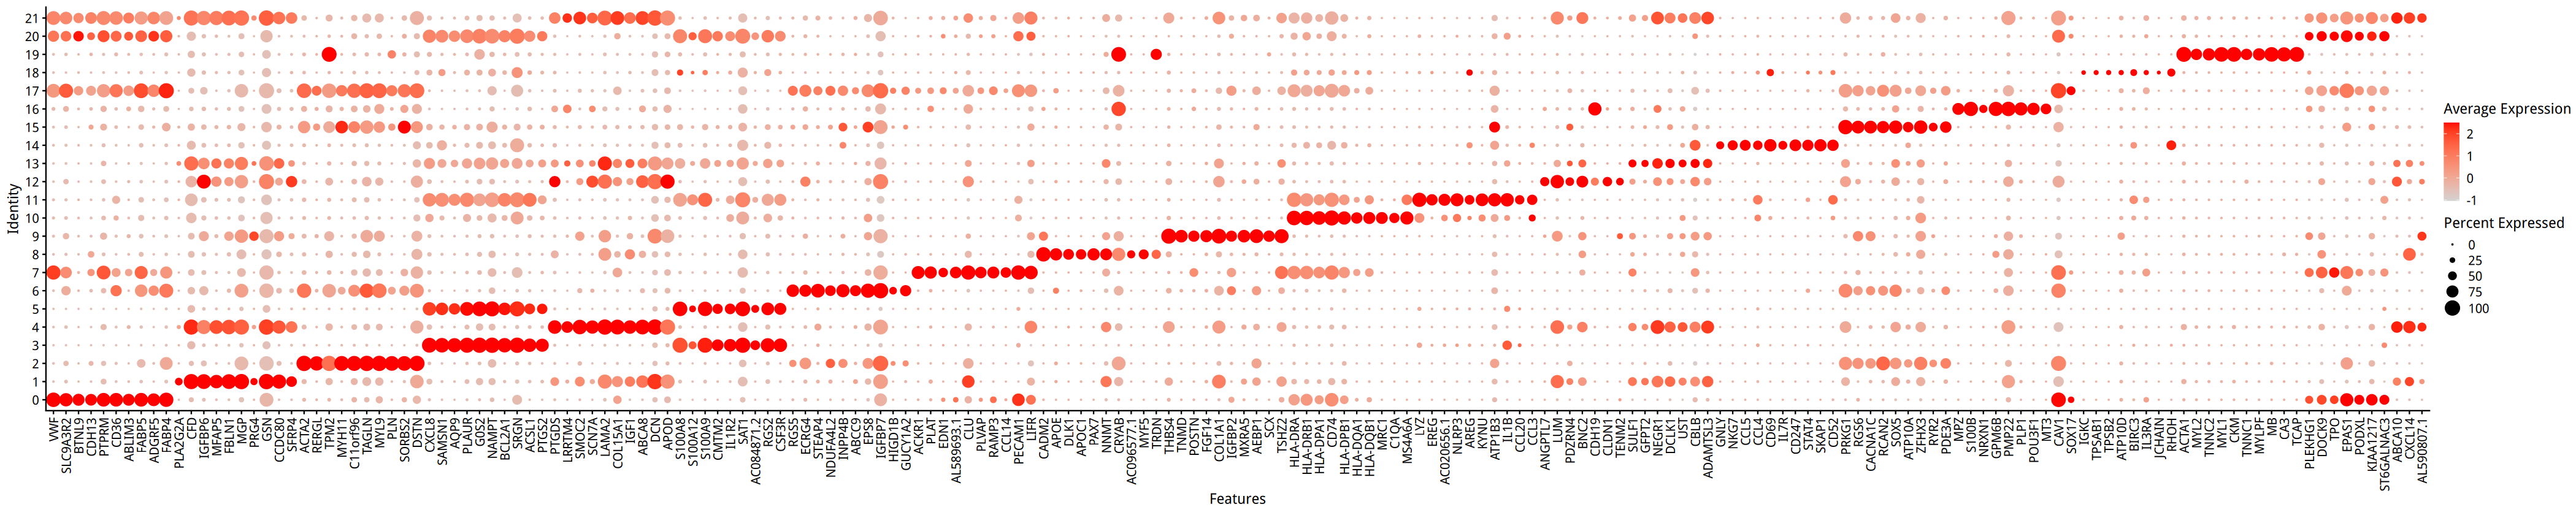

In [26]:
options(repr.plot.width = 35, repr.plot.height = 7)
DotPlot(data, features = unique(top10$gene), cols = c("lightgrey", "red")) + theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5))
ggsave("result/2.UMAP/scRNA/dotplot.top10.pdf", width = 35, height = 7)

In [15]:
markerlist = list(
    T = "CD3D,CD3E,CD3G",
    B = "RHOH,CD79A,MS4A1",
    Neutrophil = "CSF3R,S100A8,S100A9,FCGR3B,TREM1,FPR1",
    "Mo/Mac" = "CSF1R,CD1C,CST3,C1QA,C1QB,CCL3,HLA-DRA,HLA-DPA1,CD68",
    Endo = "PECAM1,VWF,CDH5",
    Capillarylartery = "FABP4,SOX17,FLT1",
    Vein = "ACKR1,SELE,PLVAP",
    Lymphaatic = "CCL21,MMRN1,NR2F1,PKHD1L1",
    FAP = "DCN,COL1A1,COL3A1,FBLN1,FBLN2,PCOLCE2",
    Fibro  = "CLDN1,TENM2,TAC1",
    Tenocyte = "TNMD,THBS4,POSTN,COMP,SCX,COL11A1",
    Pericyte = "ABCC9,STEAP4,KCNJ8",
    SMC = "ACTA2,RGS5,MYH11,MYOCD,NDUFA4L2,MCAM",
    MuSC = "DLK1,APOE,PAX7,MYF5,TENM4,CALCR",
    "Myofibre I" = "MYH7,TNNT1",
    "Myofibre II" = "MYH1,MYH2",
    Schwann = "MPZ,PMP22,MBP,CDH19",
    Neuron = "TSHZ2,TENM3",
    Monocyte = "LYZ,FCN1,CTSS"
)
markerlist = lapply(markerlist, function(x) unlist(strsplit(x, ",|, ")))

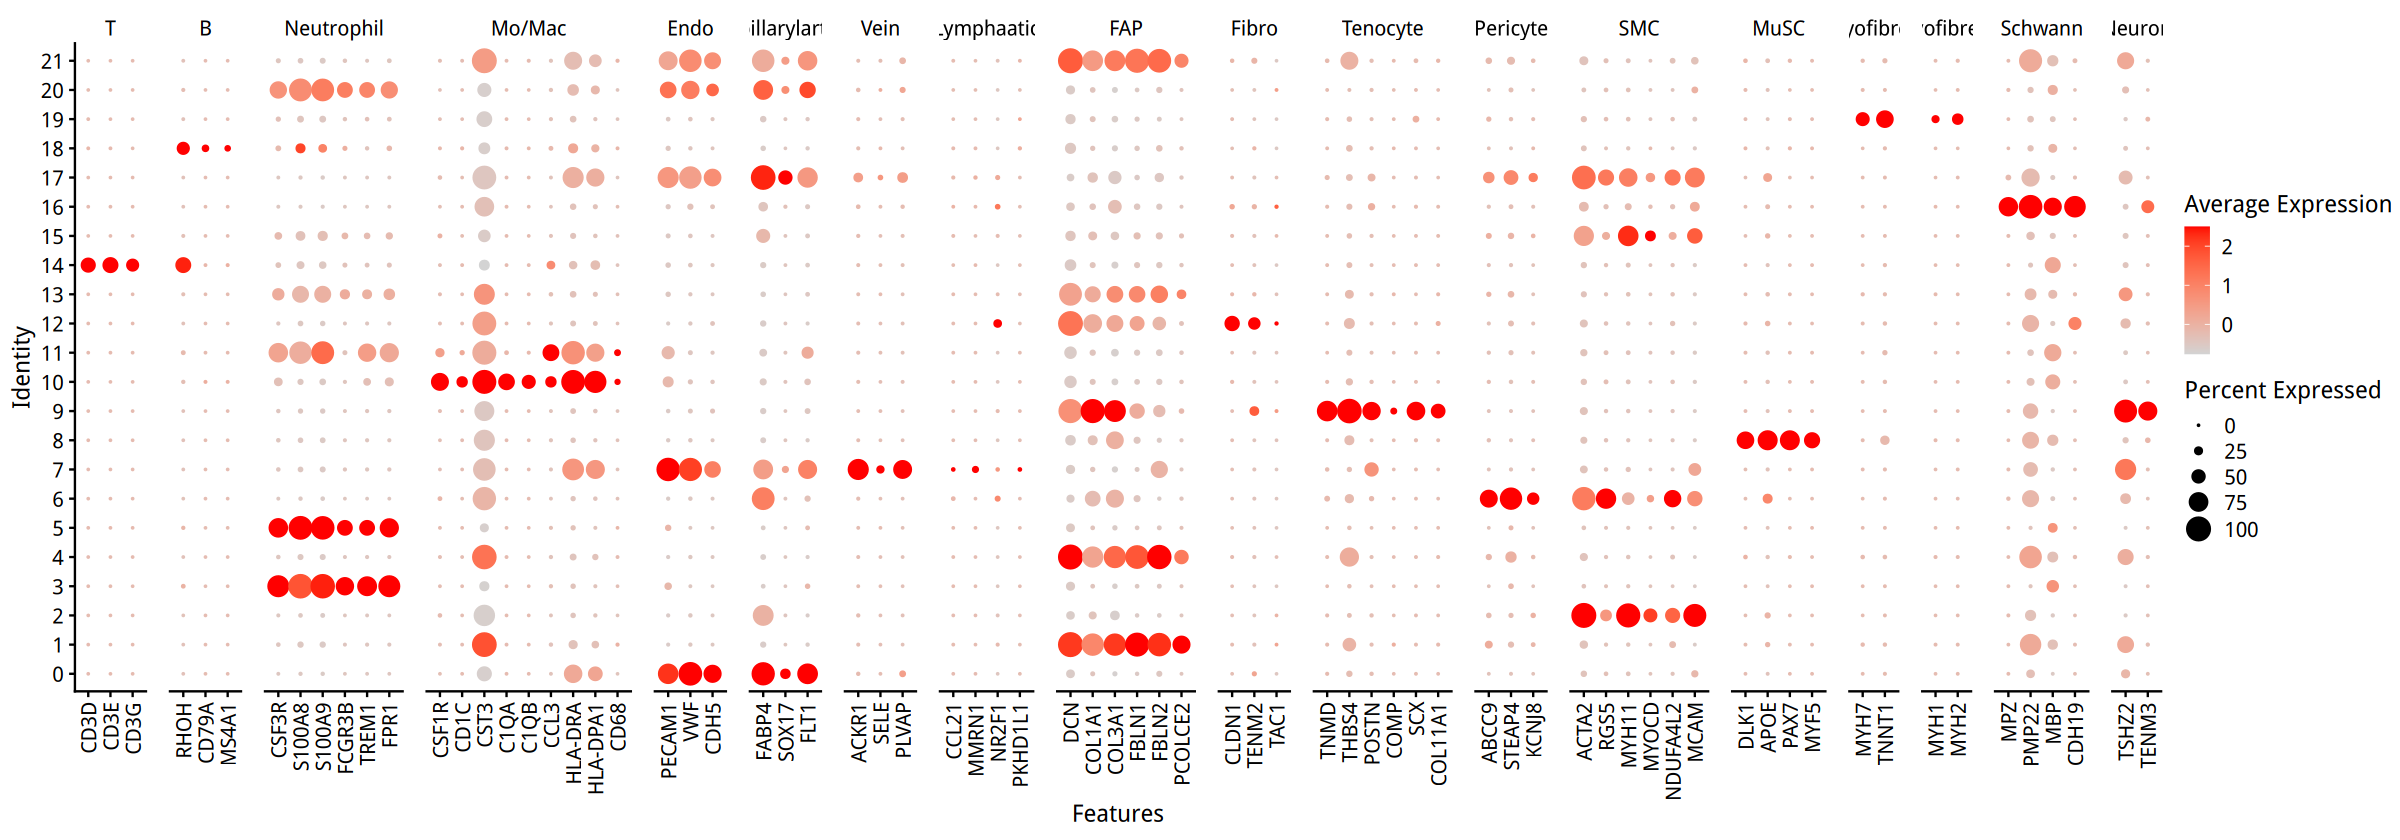

In [30]:
options(repr.plot.width = 20, repr.plot.height = 7)
DotPlot(data, features = markerlist, cols = c("lightgrey", "red")) + theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5))

In [31]:
deg %>% filter(cluster == 18) %>% filter(avg_log2FC > 2)

,p_val,auc,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
RHOH.1,0.000000e+00,0.7131983,2.617425,0.443,0.019,0.000000e+00,18,RHOH
CD69.2,0.000000e+00,0.6817784,2.933382,0.381,0.021,0.000000e+00,18,CD69
CPA3,0.000000e+00,0.6114573,2.417234,0.223,0.001,0.000000e+00,18,CPA3
TPSB2,0.000000e+00,0.6095934,3.445463,0.220,0.001,0.000000e+00,18,TPSB2
TPSAB1,0.000000e+00,0.6060171,3.481068,0.212,0.000,0.000000e+00,18,TPSAB1
HDC,0.000000e+00,0.5892242,2.123024,0.179,0.001,0.000000e+00,18,HDC
CTSG,0.000000e+00,0.5821810,2.487328,0.165,0.001,0.000000e+00,18,CTSG
IGHM,0.000000e+00,0.5728450,2.056947,0.147,0.001,0.000000e+00,18,IGHM
CLC,0.000000e+00,0.5724299,2.552766,0.147,0.002,0.000000e+00,18,CLC


## remove cluster 20 and cluster 21
We find two clusters, 20 and 21, is the doublets.So we filer the two clusters and re-dim.
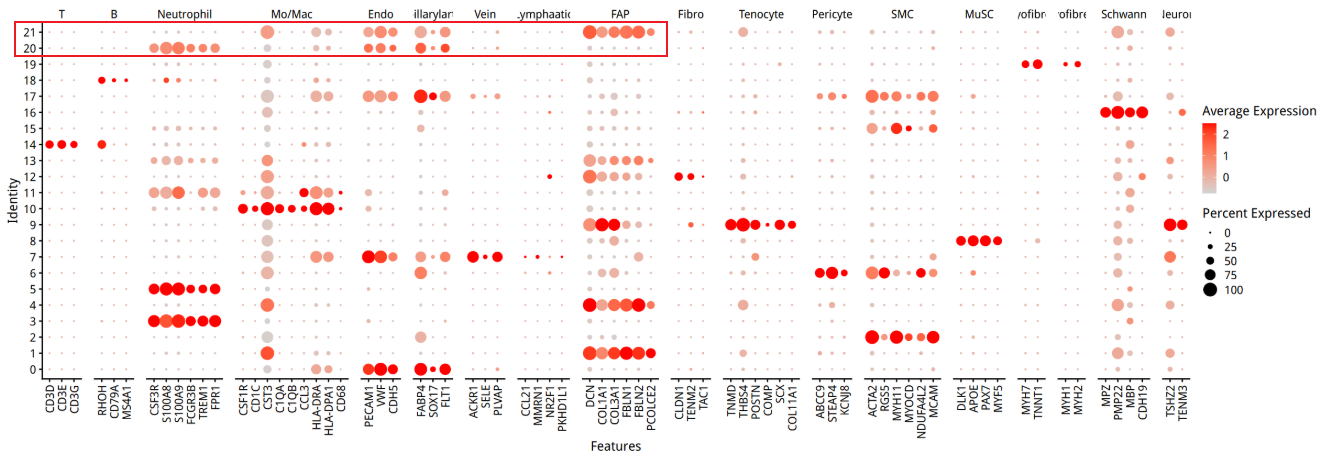

In [32]:
data = subset(data, cluster %in% c("20", "21"), invert = TRUE)

In [33]:
data = NormalizeData(data, verbose = F) %>% 
    FindVariableFeatures(verbose = F) %>% 
    ScaleData(verbose = F) %>% 
    RunPCA(verbose = F)

In [34]:
dims = 1:15
data = RunHarmony(data, group.by.vars = "Sample", verbose = F)
data = RunUMAP(data, dims = dims, reduction = "harmony", verbose = F)
data = FindNeighbors(data, dims = dims, reduction = "harmony", verbose = F)
data = FindClusters(data, resolution = 1:10/10, verbose = F)

Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 5539900)”
Warning message:
“Invalid name supplied, making object name syntactically valid. New object name is Seurat..ProjectDim.RNA.harmony; see ?make.names for more details on syntax validity”
Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”


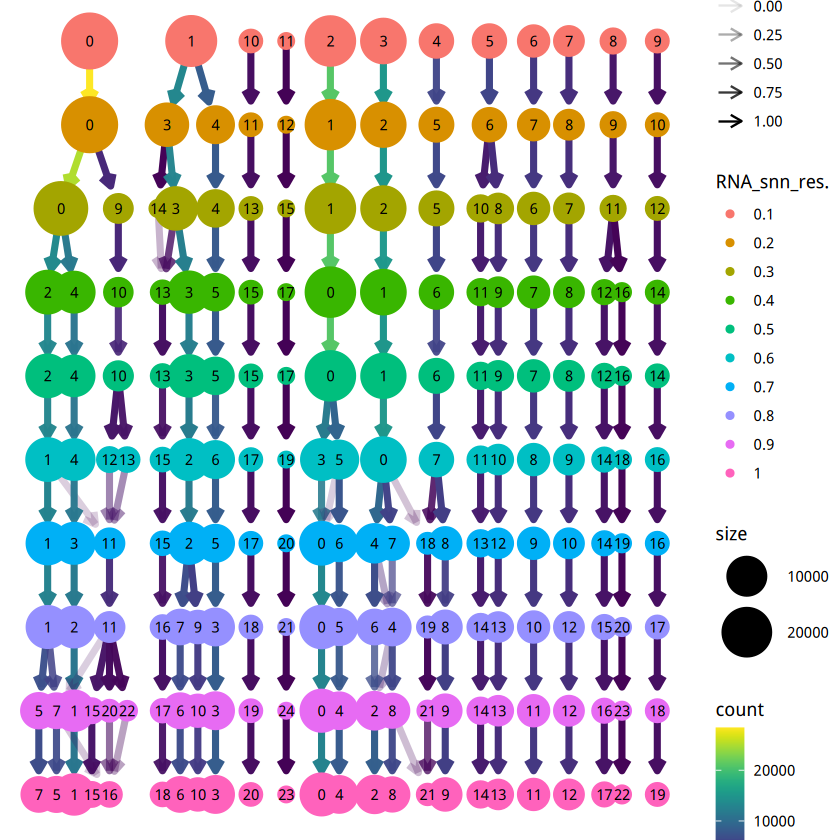

In [35]:
options(repr.plot.width = 7, repr.plot.height = 7)
clustree(data, prefix = "RNA_snn_res.")

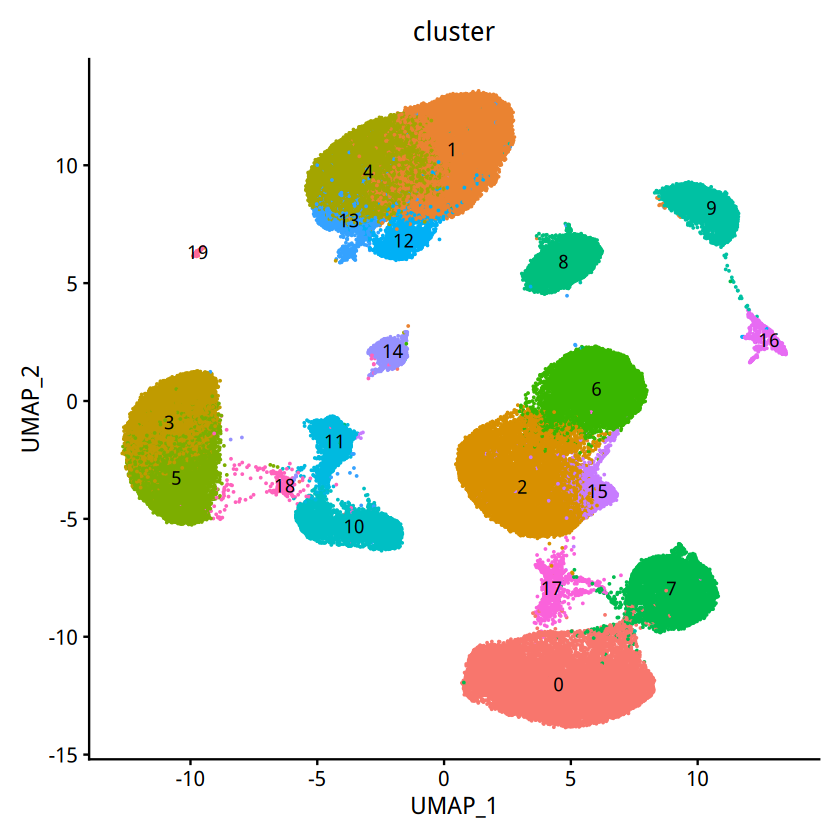

In [36]:
Idents(data) = "RNA_snn_res.0.6"
data$cluster = Idents(data)
DimPlot(data, group.by = "cluster", raster = FALSE, label = TRUE) + NoLegend()

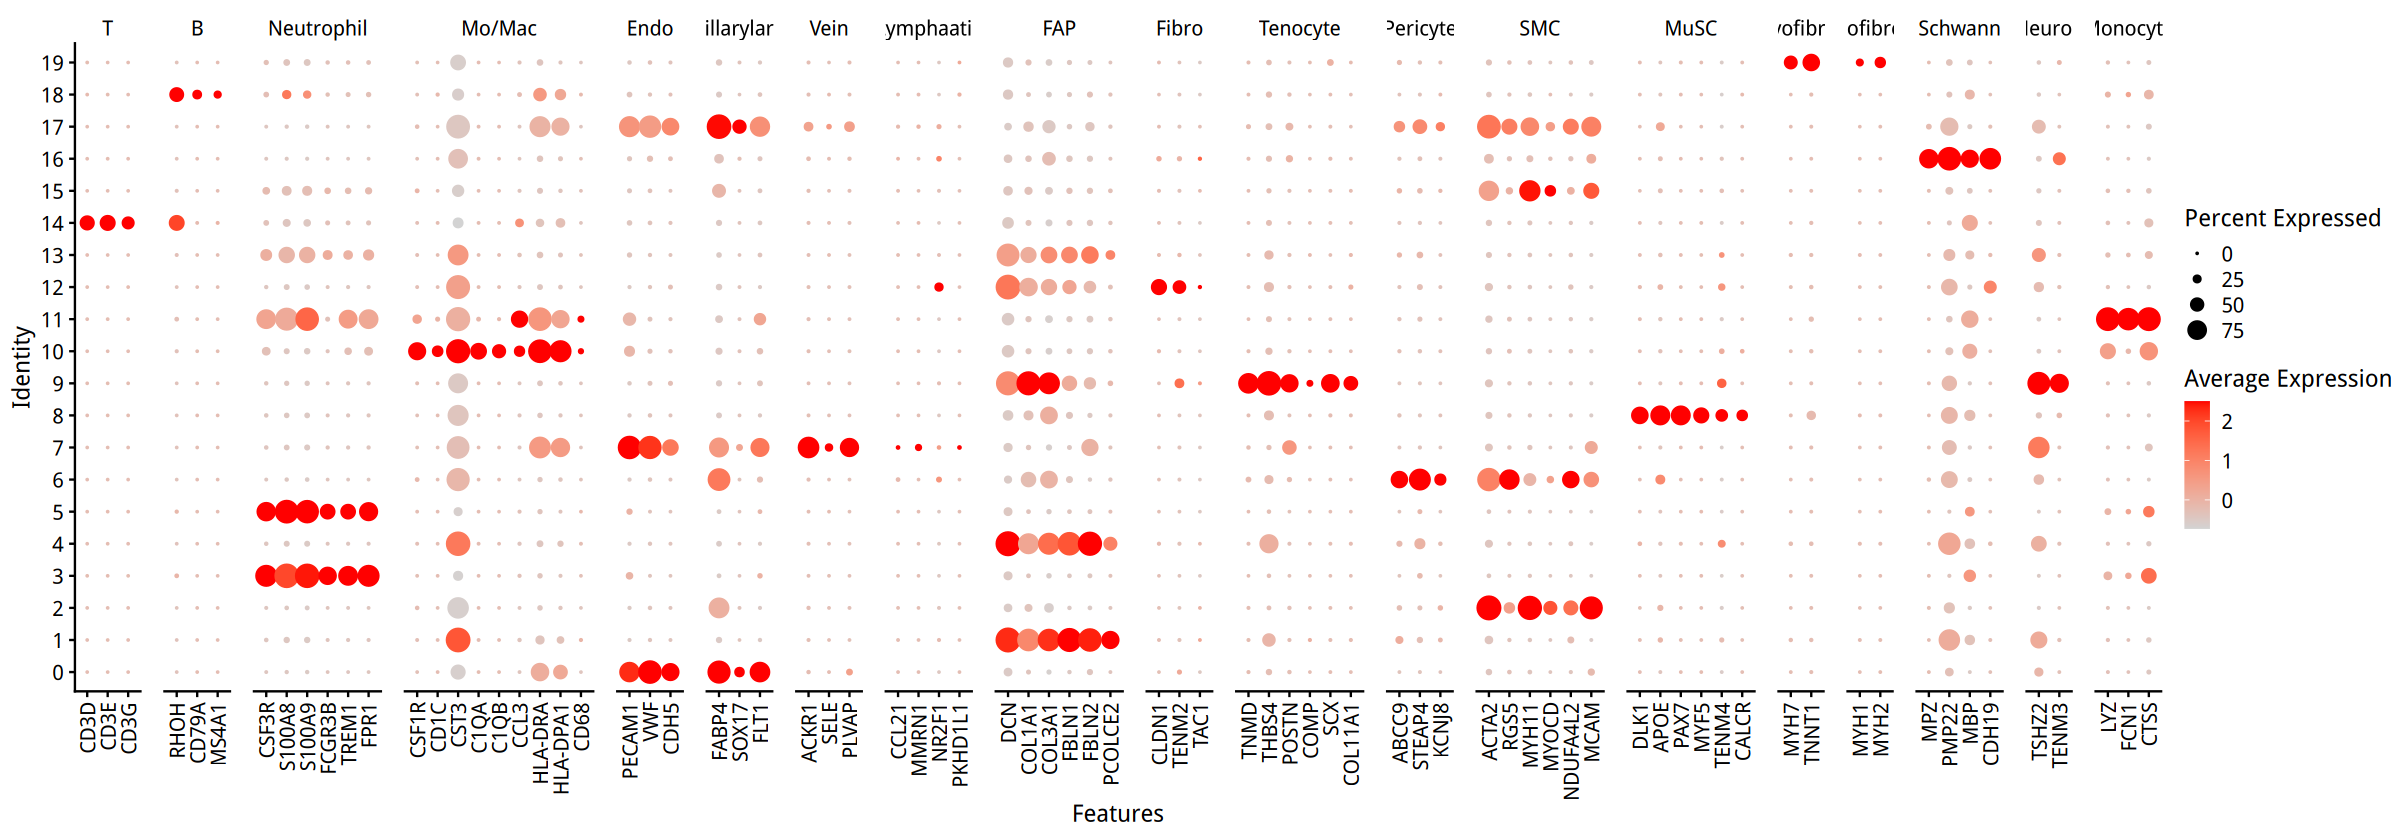

In [16]:
options(repr.plot.width = 20, repr.plot.height = 7)
DotPlot(data, features = markerlist, cols = c("lightgrey", "red")) + theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5))

In [60]:
Idents(data) = "cluster"
deg = RunPrestoAll(data, verbose = F)
top10 = deg %>% group_by(cluster) %>% slice_max(avg_log2FC, n = 10)

In [61]:
deg %>% filter(cluster == 11) %>% filter(avg_log2FC > 2)

,p_val,auc,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
LYZ.6,0,0.9596854,4.547449,0.941,0.073,0,11,LYZ
FCN1.1,0,0.9277112,3.007725,0.882,0.029,0,11,FCN1
CTSS.11,0,0.9245333,2.597605,0.946,0.167,0,11,CTSS
NLRP3.1,0,0.9090406,3.388588,0.846,0.038,0,11,NLRP3
KYNU.1,0,0.9036115,3.197883,0.821,0.020,0,11,KYNU
SIPA1L1.10,0,0.9007135,2.421798,0.947,0.287,0,11,SIPA1L1
FCER1G.11,0,0.8964629,2.203933,0.929,0.136,0,11,FCER1G
IL1B.11,0,0.8950400,3.192323,0.882,0.124,0,11,IL1B
CD83.11,0,0.8937332,2.135953,0.891,0.104,0,11,CD83


In [32]:
data$Group = factor(data$Group, levels = c("Right", "Left", "Convex", "Concave"))

In [4]:
data = readRDS("result//scRNA_seurat.rds")
#Idents(data) = "clsuter"

In [8]:
Idents(data) = "cluster"
unique(Idents(data))

[1] 3  7  5  6  11 19 13 0  4  9  1  8  2  12 15 10 14 18 17 16
Levels: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19

In [10]:
anno_df = read.table("scRNA_markerlist.txt", sep = "\t", header = TRUE)
anno_df
celltype = anno_df$CellType
names(celltype) = anno_df$Cluster
data = RenameIdents(data, celltype)

Cluster,Markers,CellType
<int>,<chr>,<chr>
0,"FABP4,SOX17,FLT1",EC(capillary_or_artery)
17,"FABP4,SOX17,FLT1",EC(capillary_or_artery)
7,"ACKR1,SELE,PLVAP",EC(vein)
1,"DCN,COL1A1,COL3A1,FBLN1,FBLN2",FAP
4,"DCN,COL1A1,COL3A1,FBLN1,FBLN2",FAP
13,"DCN,COL1A1,COL3A1,FBLN1,FBLN2",FAP
12,"CLDN1,TENM2,TAC1",Fibroblast
2,"ACTA2,MYH11,MCAM",SMC
15,"ACTA2,MYH11,MCAM",SMC


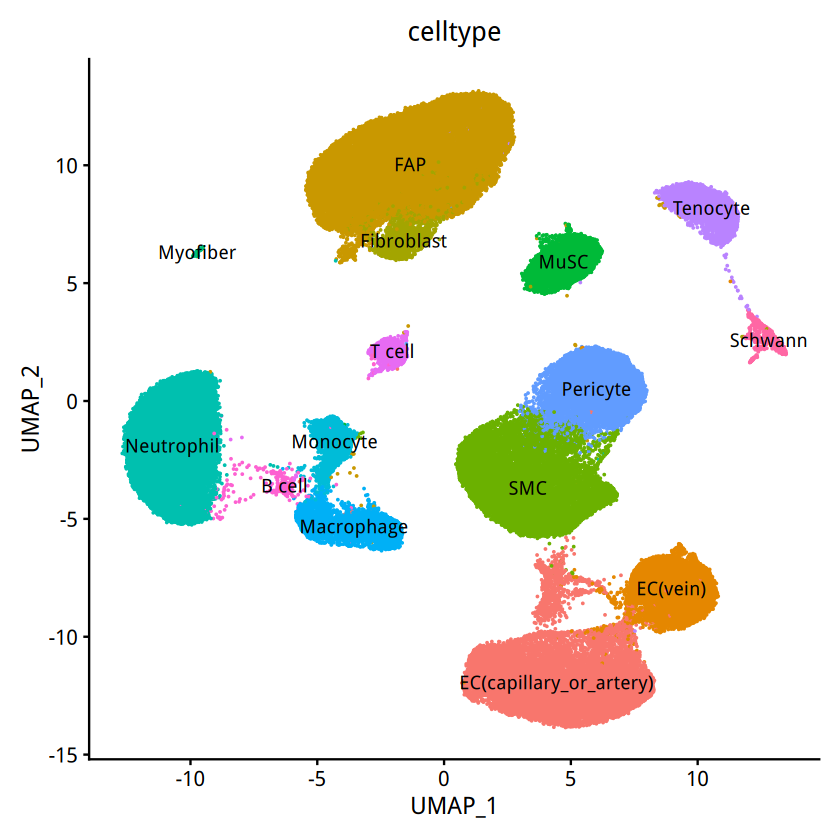

In [14]:
options(repr.plot.width = 7, repr.plot.height = 7)
data$celltype = Idents(data)
DimPlot(data, group.by = "celltype", raster = FALSE, label = TRUE) + NoLegend()

In [17]:
df = melt(table(data$Sample, data$Group, data$CellType))
colnames(df) = c("Sample", "Group", "Celltype", "cell_num")
df = subset(df, cell_num != 0)

## stat group
Calculate the proportion of red MuSCs in each group

In [20]:
df = df %>% group_by(Sample) %>% mutate(ratio = round(cell_num / sum(cell_num) * 100, 2))
head(df)

Sample,Group,Celltype,cell_num,ratio
<fct>,<fct>,<fct>,<int>,<dbl>
AIS1AC,Concave,Capillarylartery,471,6.54
AIS2AC,Concave,Capillarylartery,185,3.65
AIS3AC,Concave,Capillarylartery,64,1.34
AIS7AC,Concave,Capillarylartery,2338,27.63
AIS8AC,Concave,Capillarylartery,2497,20.67
AIS1TC,Convex,Capillarylartery,284,2.49


In [25]:
df$Group = factor(df$Group, levels = c("Right", "Left", "Convex", "Concave"))
used.df = subset(df, Celltype == "MuSC")

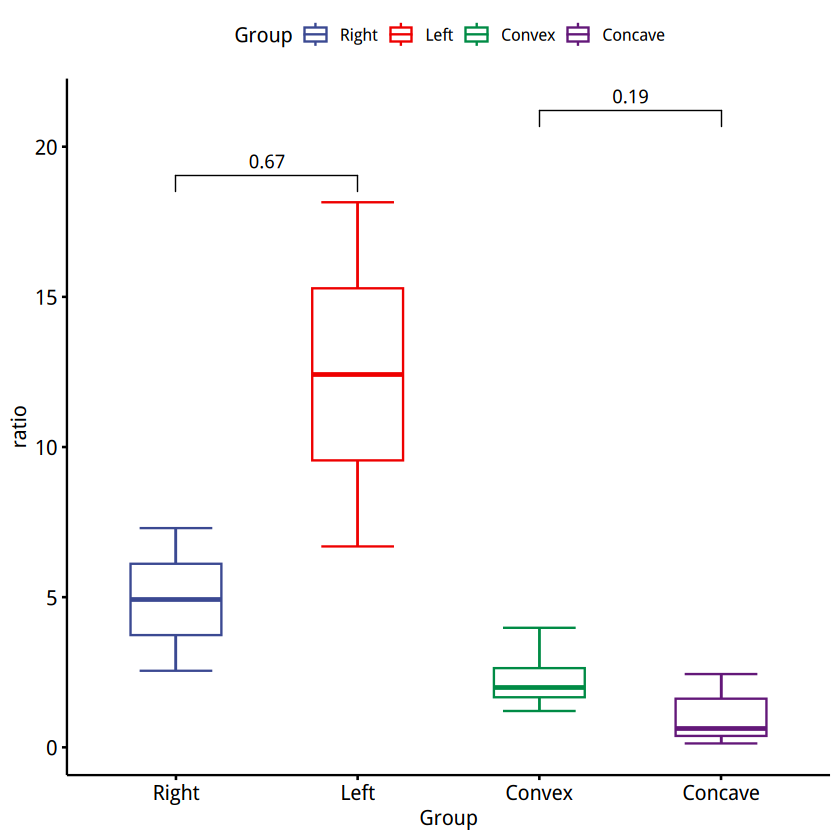

In [28]:
cmp = list(c("Right", "Left"), c("Convex", "Concave"))
ggboxplot(used.df, x = "Group", y = "ratio", width = 0.5, color = "Group", palette="aaas", bxp.errorbar=T) + stat_compare_means(comparisons = cmp, method = "wilcox.test")

# snRNA

## QC
1. get sample name and group name   
3. Filter cells: nCount_RNA < 15000 & nFeature_RNA > 200 & nFeature_RNA < 6000 & percent.mt < 10

In [47]:
sampledf = read.csv("snRNA_sample.txt", header = F)
groupdf = read.table("grouplist.txt", header = F, sep = "\t")
colnames(groupdf) = c("sample", "group")
samplelist = sampledf$V1

In [48]:
data.list = lapply(samplelist, function(x){
    print(x)
    obj = readRDS(file.path("DoubleFinder", x, "result.rds"))
    obj$Sample = x
    return(obj)
})

[1] "AIS1AN"
[1] "AIS1TN"
[1] "AIS2AN"
[1] "AIS2TN"
[1] "AIS3AN"
[1] "AIS4TN"
[1] "CON1LN"
[1] "CON1RN"
[1] "CON3LN"
[1] "CON3RN"
[1] "CON7LN"


In [49]:
data = merge(data.list[[1]], data.list[-1])
data$Group = groupdf$group[match(data$Sample, groupdf$sample)]

In [50]:
data$percent.mt = PercentageFeatureSet(data, pattern = "MT-")

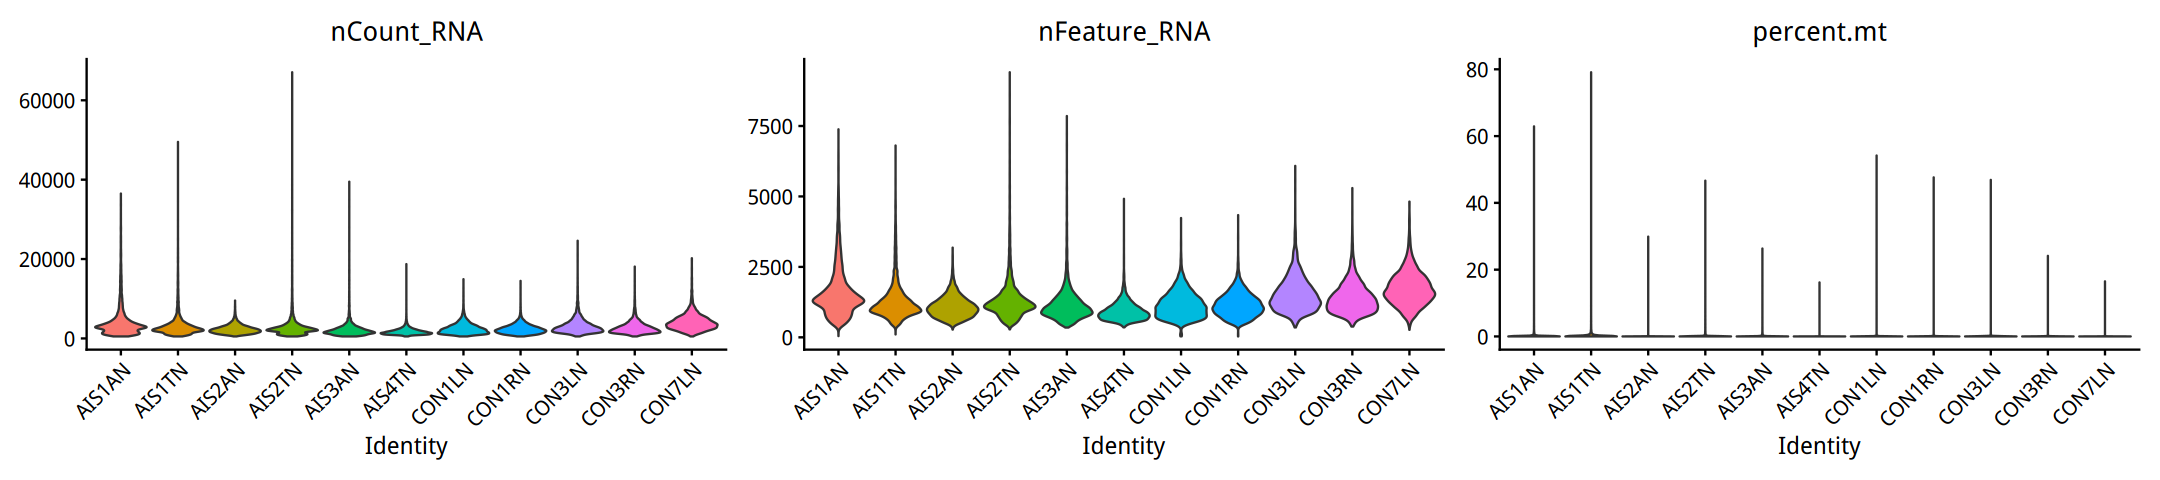

In [51]:
options(repr.plot.width = 18, repr.plot.height = 4)
VlnPlot(data, group.by = "Sample", features = c("nCount_RNA", "nFeature_RNA", "percent.mt"), pt.size = 0, raster = FALSE) + NoLegend()
outdir = "result/1.QC/snRNA"
if (!dir.exists(outdir)) dir.create(outdir, recursive = TRUE)
ggsave(file.path(outdir, "QC_before.pdf"), width = 18, height = 4)

In [52]:
data = subset(data, nCount_RNA < 10000 & nFeature_RNA > 200 & nFeature_RNA < 4000 & percent.mt < 10)

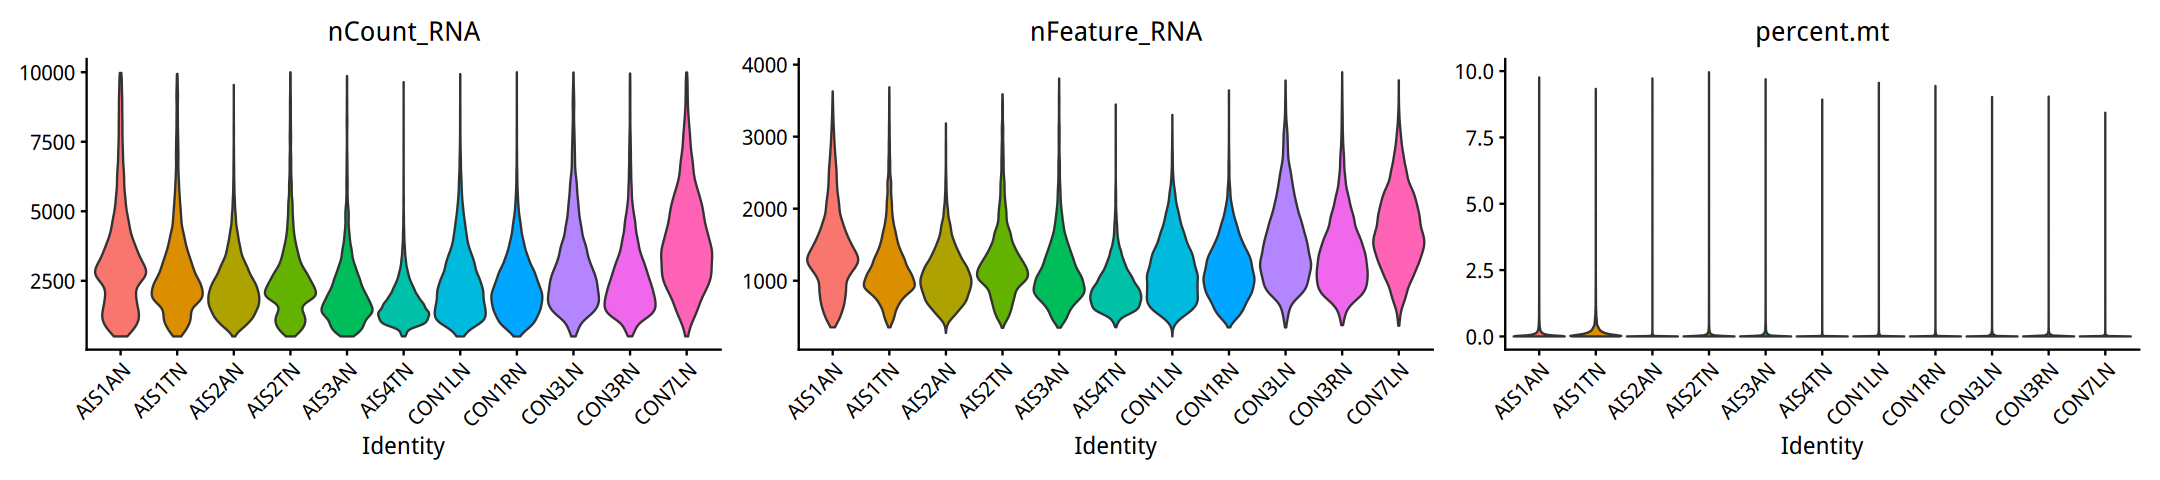

In [57]:
options(repr.plot.width = 18, repr.plot.height = 4)
VlnPlot(data, group.by = "Sample", features = c("nCount_RNA", "nFeature_RNA", "percent.mt"), pt.size = 0, raster = FALSE) + NoLegend()
outdir = "result/1.QC/snRNA"
if (!dir.exists(outdir)) dir.create(outdir, recursive = TRUE)
ggsave(file.path(outdir, "QC_after.pdf"), width = 18, height = 4)

## Dimensionality and Reduction

In [55]:
data = NormalizeData(data, verbose = F) %>% FindVariableFeatures(verbose = F) %>% ScaleData(verbose = F) %>% RunPCA(verbose = F)

When using repel, set xnudge and ynudge to 0 for optimal results

Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”


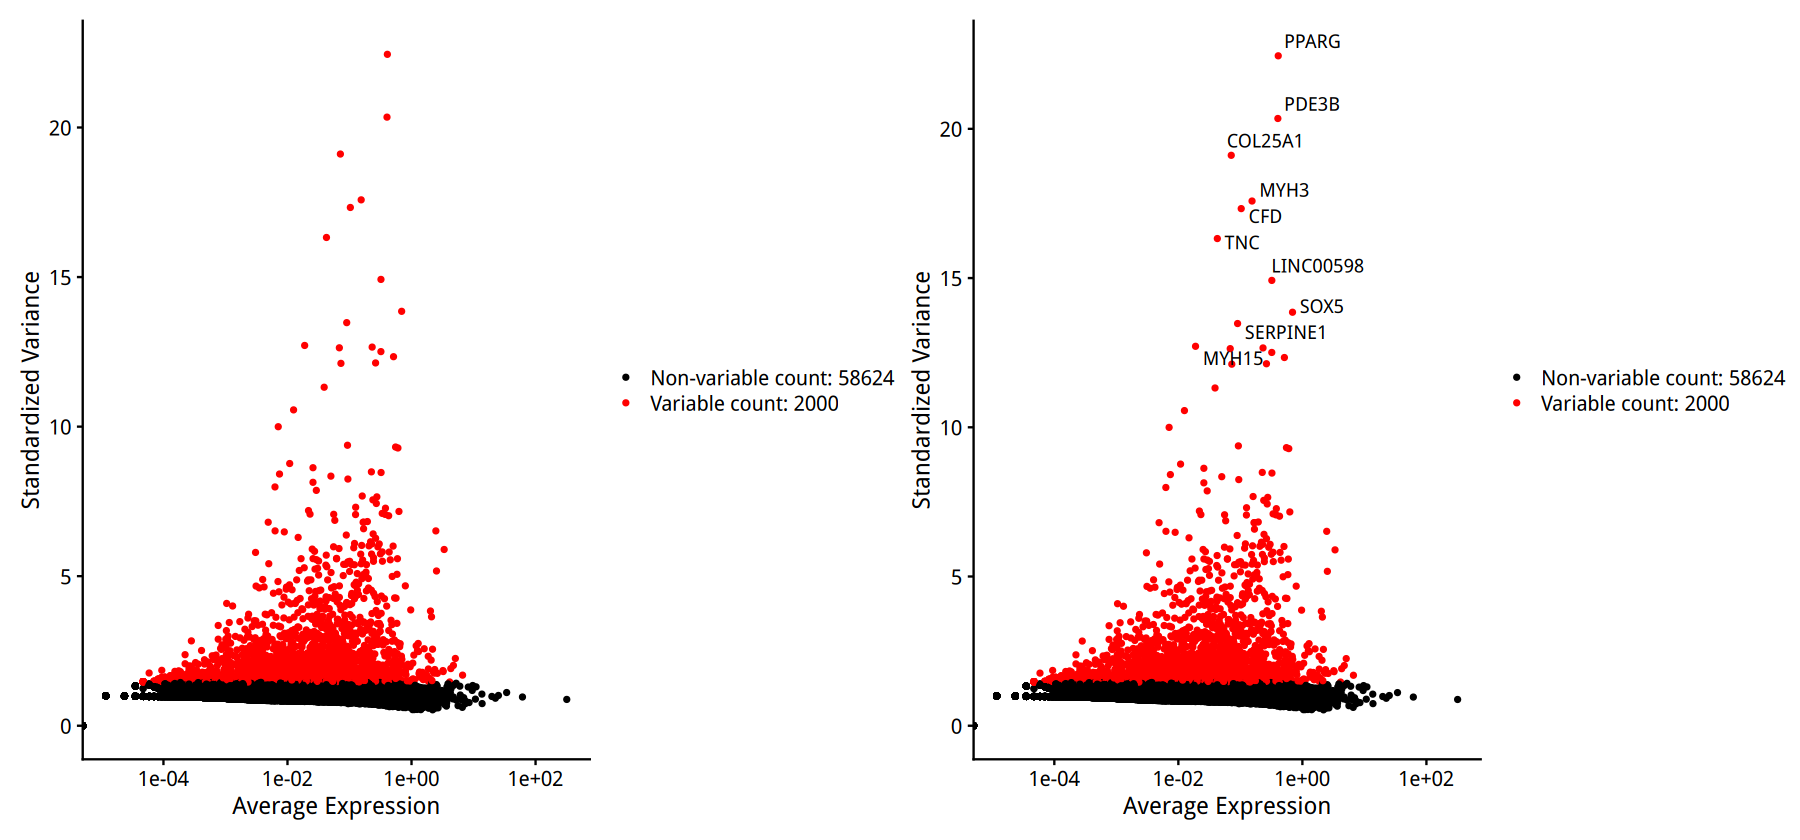

In [32]:
options(repr.plot.width = 15, repr.plot.height = 7)
top10 <- head(VariableFeatures(data), 10)
plot1 <- VariableFeaturePlot(data)
plot2 <- LabelPoints(plot = plot1, points = top10, repel = TRUE)
plot1 + plot2

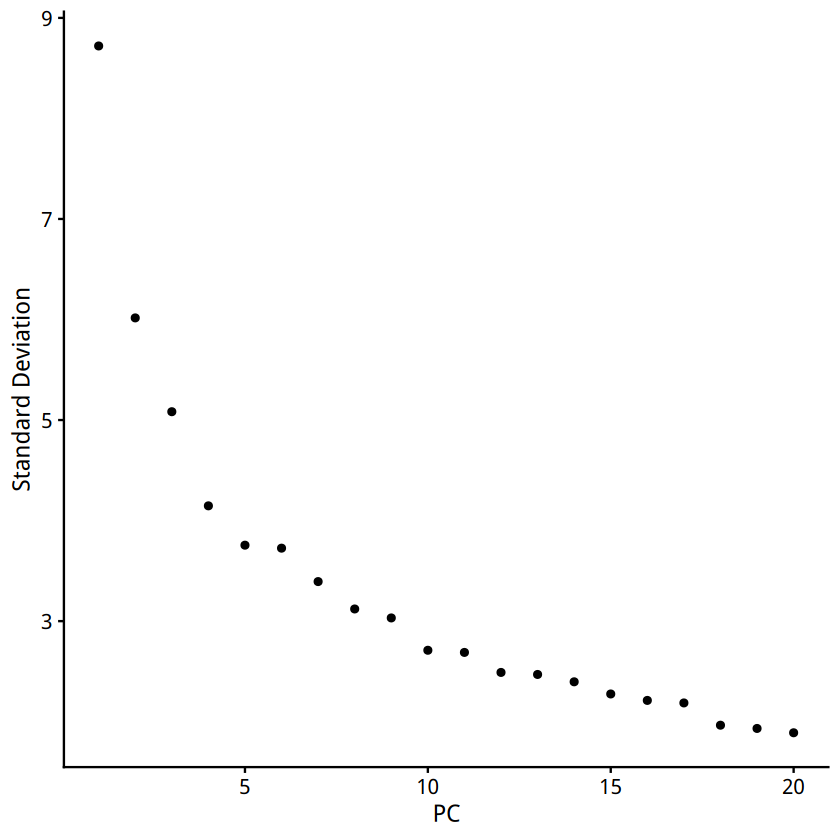

In [56]:
options(repr.plot.width = 7, repr.plot.height = 7)
ElbowPlot(data)

In [58]:
dims = 1:10
data = RunHarmony(data, group.by.vars = "Sample", verbose = F)
data = RunUMAP(data, dims = dims, reduction = "harmony", verbose = F)
data = FindNeighbors(data, dims = dims, reduction = "harmony", verbose = F)
data = FindClusters(data, resolution = 1:10/10, verbose = F)

Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 4255350)”
Warning message:
“Invalid name supplied, making object name syntactically valid. New object name is Seurat..ProjectDim.RNA.harmony; see ?make.names for more details on syntax validity”


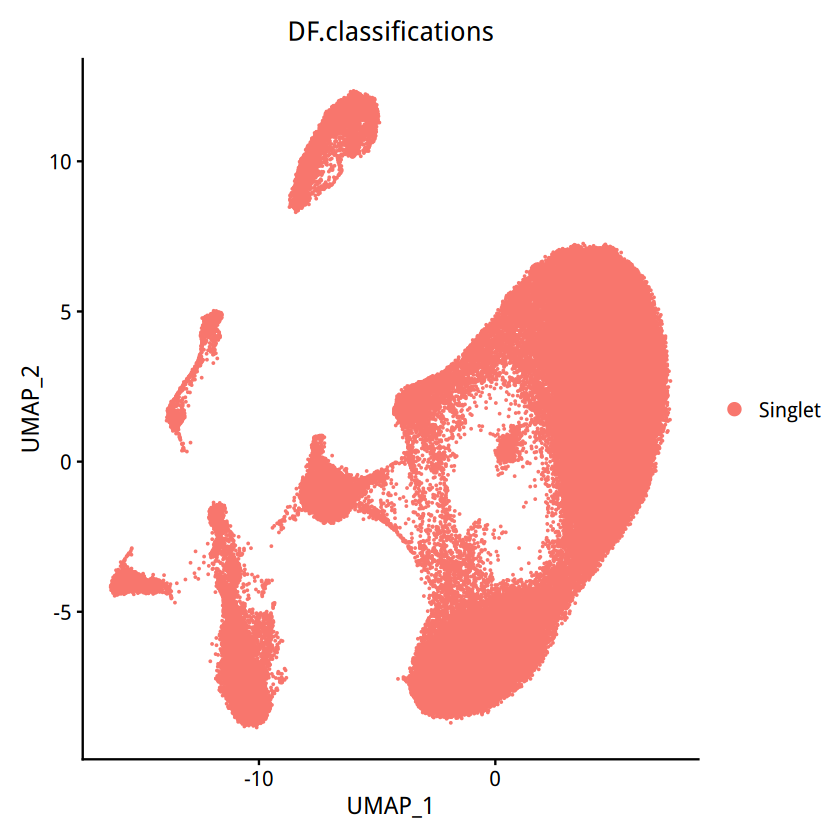

In [65]:
options(repr.plot.width = 7, repr.plot.height = 7)
DimPlot(data, group.by = "DF.classifications", raster = FALSE)
outdir = "result/2.UMAP/snRNA"
if (!dir.exists(outdir)) dir.create(outdir, recursive = TRUE)
ggsave(file.path(outdir, "umap.DoubletFinder.pdf"), width = 7, height = 7)

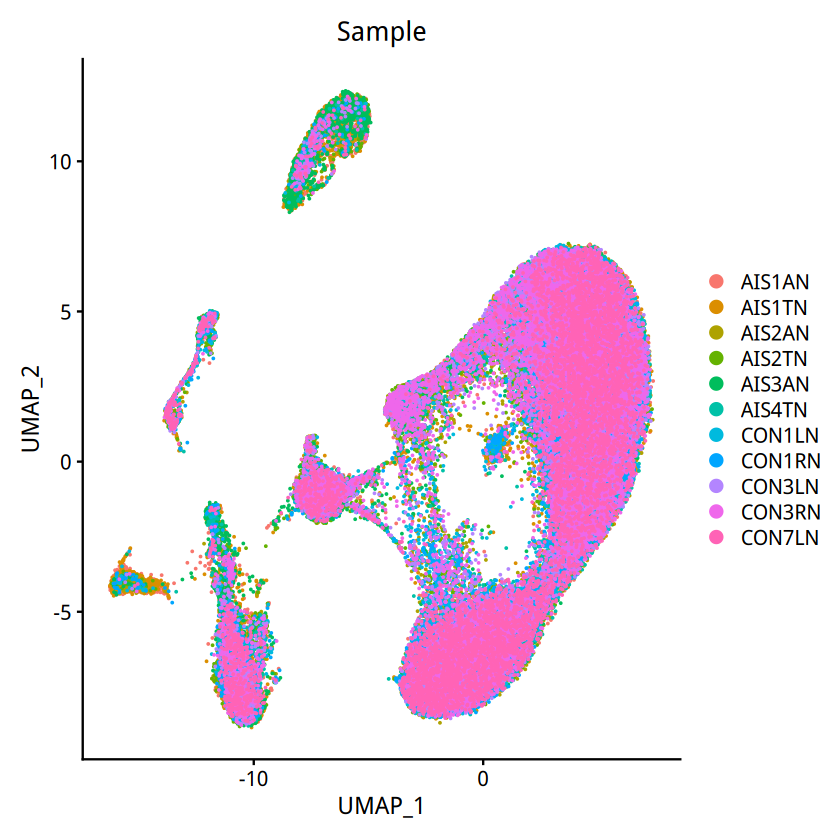

In [66]:
options(repr.plot.width = 7, repr.plot.height = 7)
DimPlot(data, group.by = "Sample", raster = FALSE)
outdir = "result/2.UMAP/snRNA"
if (!dir.exists(outdir)) dir.create(outdir, recursive = TRUE)
ggsave(file.path(outdir, "umap.sample.pdf"), width = 7, height = 7)

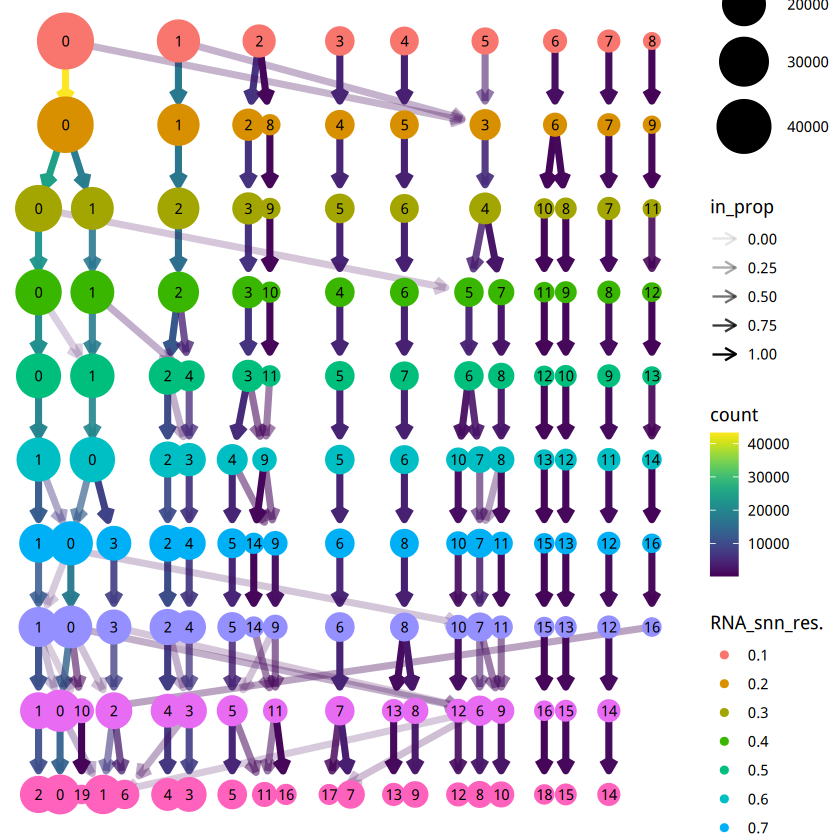

In [63]:
options(repr.plot.width = 7, repr.plot.height = 7)
clustree(data, prefix = "RNA_snn_res.")
outdir = "result/2.UMAP/snRNA"
if (!dir.exists(outdir)) dir.create(outdir, recursive = TRUE)
ggsave(file.path(outdir, "clustree.pdf"), width = 7, height = 7)

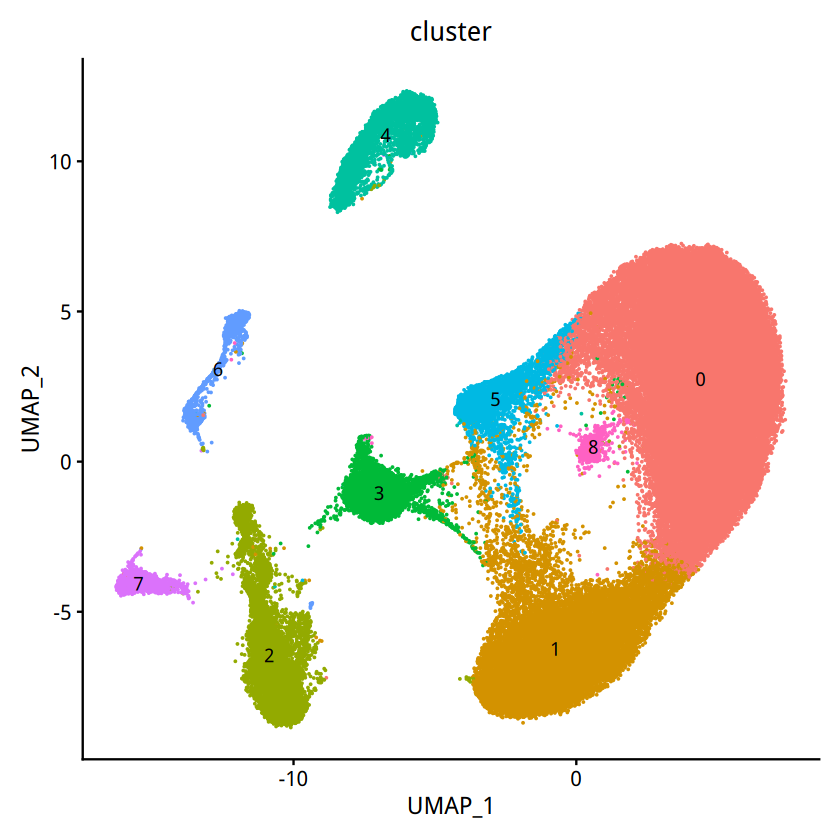

In [62]:
Idents(data) = "RNA_snn_res.0.1"
data$cluster = Idents(data)
DimPlot(data, group.by = "cluster", raster = FALSE, label = TRUE) + NoLegend()
outdir = "result/2.UMAP/snRNA"
if (!dir.exists(outdir)) dir.create(outdir, recursive = TRUE)
ggsave(file.path(outdir, "umap.cluster.pdf"), width = 7, height = 7)

In [64]:
saveRDS(data, "result/snRNA_seurat.rds")

## Define clusters
To Define clusters, we should to get the top markers for every clusters.

In [15]:
data = readRDS("result/snRNA_seurat.rds")

In [16]:
data$Group = factor(data$Group, levels = c("Right", "Left", "Convex", "Concave"))

In [37]:
unique(data$Group)

[1] Concave Convex  Left    Right  
Levels: Right Left Convex Concave

In [29]:
df = data.frame(table(data$Sample, data$Group))
colnames(df) = c("Sample", "Group", "Cell_Number")
df = df[df$Cell_Number != 0,]
write.table(df, "sample_stat.txt", sep = "\t", row.names = F, quote = F)

In [9]:
Idents(data) = "cluster"
deg = RunPrestoAll(data, verbose = F)
top10 = deg %>% group_by(cluster) %>% slice_max(avg_log2FC, n = 10)

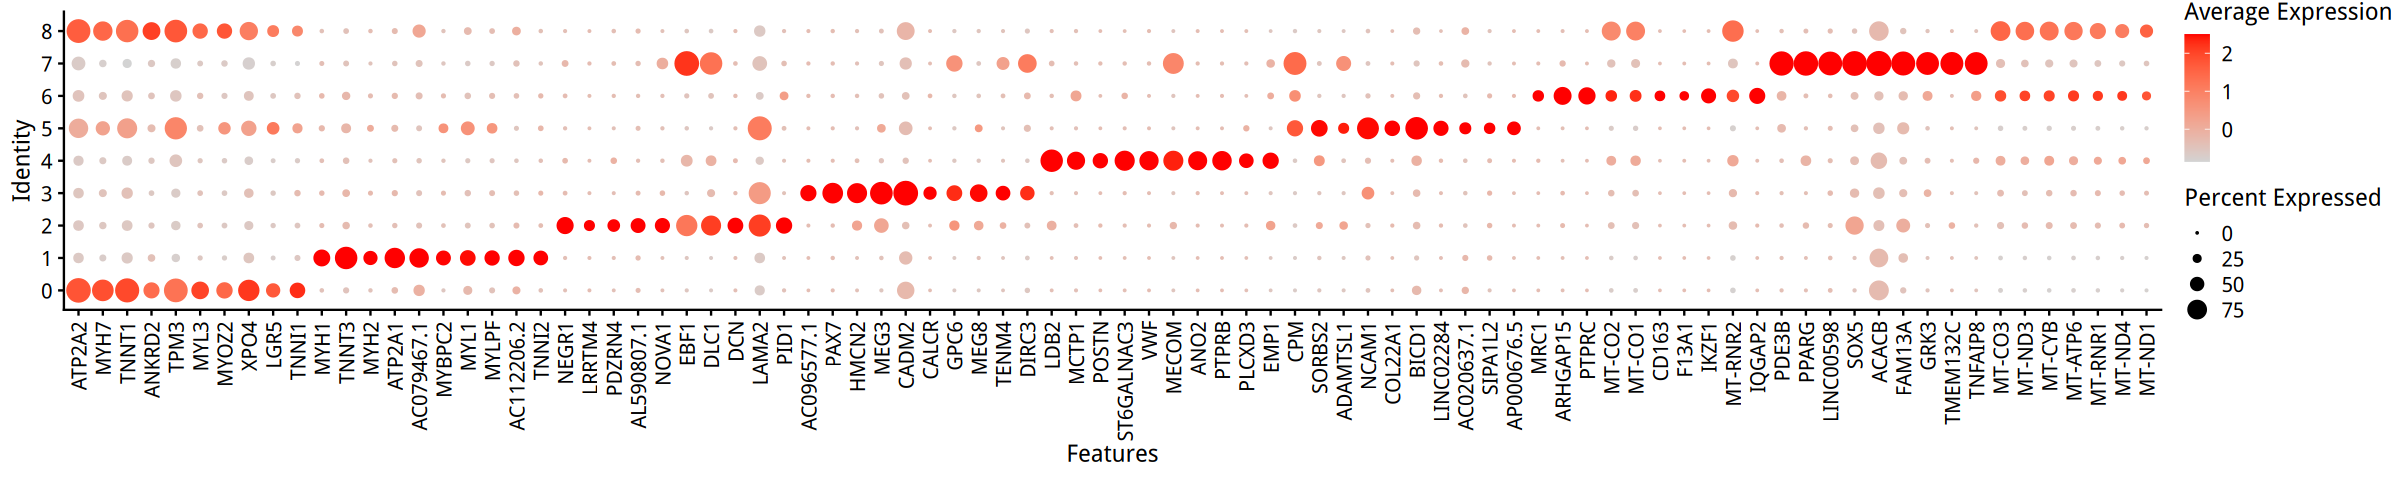

In [39]:
options(repr.plot.width = 20, repr.plot.height = 4)
DotPlot(data, features = unique(top10$gene), cols = c("lightgrey", "red")) + theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5))
ggsave("result/2.UMAP/snRNA/dotplot.top10.pdf", width = 20, height = 4)

In [12]:
markerlist = list(
    T = "CD3D,CD3E,CD3G",
    B = "RHOH,CD79A,MS4A1",
    Neutrophil = "CSF3R,S100A8,S100A9,FCGR3B,TREM1,FPR1",
    "Mo/Mac" = "CSF1R,CD1C,CST3,C1QA,C1QB,CCL3,HLA-DRA,HLA-DPA1,CD68",
    Endo = "PECAM1,VWF,CDH5",
    Capillarylartery = "FABP4,SOX17,FLT1",
    Vein = "ACKR1,SELE,PLVAP",
    Lymphaatic = "CCL21,MMRN1,NR2F1,PKHD1L1",
    FAP = "DCN,COL1A1,COL3A1,FBLN1,FBLN2,PCOLCE2",
    Fibro  = "CLDN1,TENM2,TAC1",
    Tenocyte = "TNMD,THBS4,POSTN,COMP,SCX,COL11A1",
    Pericyte = "ABCC9,STEAP4,KCNJ8",
    SMC = "ACTA2,RGS5,MYH11,MYOCD,NDUFA4L2,MCAM",
    MuSC = "DLK1,APOE,PAX7,MYF5,TENM4,CALCR",
    "Myofibre I" = "MYH7,TNNT1",
    "Myofibre II" = "MYH1,MYH2",
    Schwann = "MPZ,PMP22,MBP,CDH19",
    Neuron = "TSHZ2,TENM3",
    Adipocyte = "PPARG,PLIN1,AQP7,GPAM,ADIPOQ"
)
markerlist = lapply(markerlist, function(x) unlist(strsplit(x, ",|, ")))

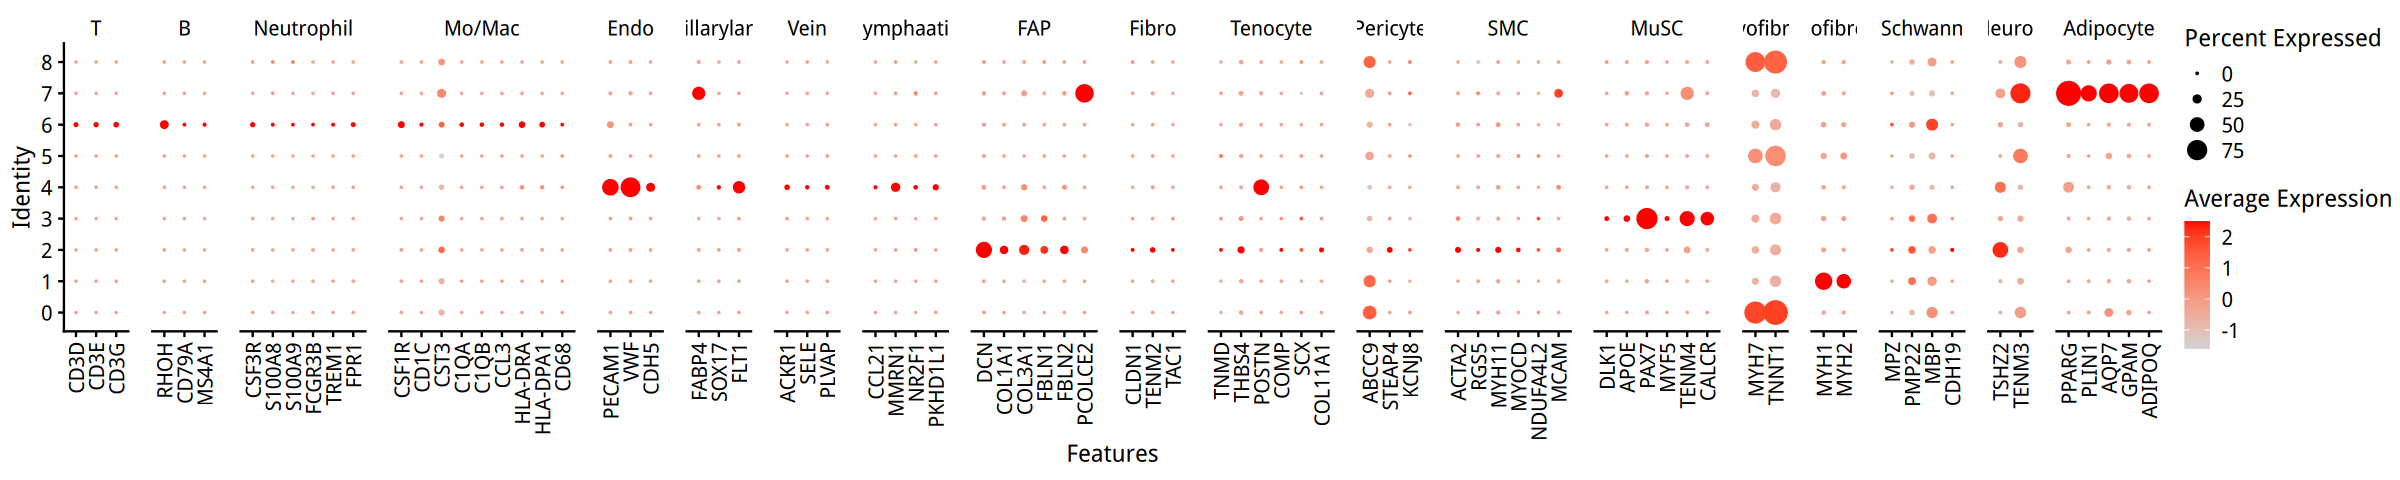

In [13]:
options(repr.plot.width = 20, repr.plot.height = 4)
DotPlot(data, features = markerlist, cols = c("lightgrey", "red")) + theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5))

In [10]:
deg %>% filter(cluster == 3) %>% filter(avg_log2FC > 2)

,p_val,auc,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
CADM2.3,0,0.9664374,3.531482,0.983,0.513,0,3,CADM2
MEG3.3,0,0.9231473,3.717091,0.885,0.082,0,3,MEG3
PAX7.1,0,0.8930112,4.206395,0.793,0.022,0,3,PAX7
HMCN2.2,0,0.8706935,3.737821,0.764,0.039,0,3,HMCN2
PLXDC2.3,0,0.8156573,2.452823,0.743,0.139,0,3,PLXDC2
MEG8.2,0,0.8071068,2.924335,0.649,0.047,0,3,MEG8
EGFR.3,0,0.8060565,2.125628,0.777,0.263,0,3,EGFR
DOCK9.2,0,0.8022754,2.794594,0.686,0.129,0,3,DOCK9
TLN2.1,0,0.8016768,2.046478,0.800,0.431,0,3,TLN2


In [17]:
anno_df = read.table("snRNA_markerlist.txt", sep = "\t", header = TRUE)
anno_df
celltype = anno_df$CellType
names(celltype) = anno_df$Cluster
Idents(data) = "cluster"
data = RenameIdents(data, celltype)

Cluster,Markers,CellType
<int>,<chr>,<chr>
0,"MYH7,TNNT1",Myofiber I
5,"MYH7,TNNT1",Myofiber I
8,"MYH7,TNNT1",Myofiber I
1,"MYH1,MYH2",Myofiber II
2,"DCN,COL1A1,COL3A1,FBLN1,FBLN2",FAP
3,"PAX7,TENM4,CALCR",MuSC
4,"PECAM1,VWF,CDH5",EC
6,"MRC1,CD163,PTPRC",Macrophage
7,"PPARG,PLIN1,AQP7",Adipocyte


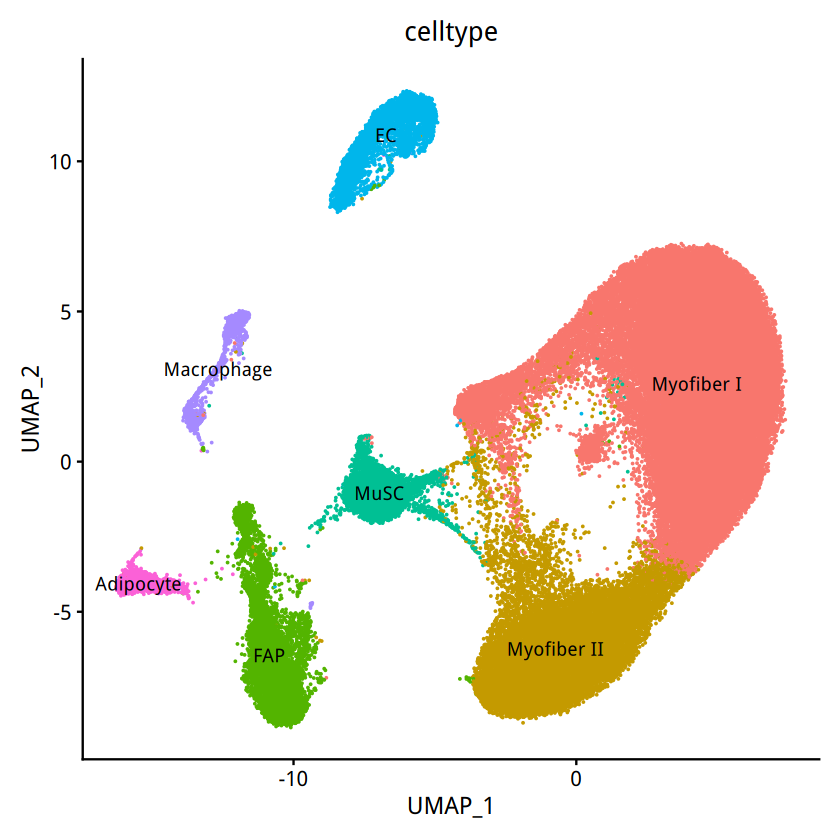

In [18]:
options(repr.plot.width = 7, repr.plot.height = 7)
data$celltype = Idents(data)
DimPlot(data, group.by = "celltype", raster = FALSE, label = TRUE) + NoLegend()